# DR23 features

In [11]:
import sys
sys.path.insert(0, '../..')
from sn_clf.scripts.utils import load_features, get_sn_label_from_akb, plot_config

import pandas as pd
import time
from coniferest.isoforest import IsolationForest
import numpy as np
import matplotlib.pyplot as plt
#from sklearn.ensemble import IsolationForest

plot_config()

In [3]:
oids, features = load_features('../../dr23-features/sid_snad_clf_r_100.dat', '../../dr23-features/feature_sn.dat')

In [4]:
n_trees = 100
random_seed = 123

In [6]:
t = time.monotonic()
iforest = IsolationForest(random_seed=random_seed, n_jobs=20, n_trees=n_trees).fit(features)
print(f'Isolation Forest was fitted in {(time.monotonic() - t)/60:.1f}')

Isolation Forest was fitted in 0.7


In [7]:
sn_threshold = []
for n_tree, tree in enumerate(iforest.trees):
    n_nodes = tree.node_count
    children_left = tree.children_left
    children_right = tree.children_right
    feature = tree.feature
    threshold = tree.threshold
    values = tree.value

    node_depth = np.zeros(shape=n_nodes, dtype=np.int64)
    is_leaves = np.zeros(shape=n_nodes, dtype=bool)
    stack = [(0, 0)]  # start with the root node id (0) and its depth (0)
    while len(stack) > 0:
        # `pop` ensures each node is only visited once
        node_id, depth = stack.pop()
        node_depth[node_id] = depth

    # If the left and right child of a node is not the same we have a split
    # node
        is_split_node = children_left[node_id] != children_right[node_id]
    # If a split node, append left and right children and depth to `stack`
    # so we can loop through them
        if is_split_node:
            stack.append((children_left[node_id], depth + 1))
            stack.append((children_right[node_id], depth + 1))
        else:
            is_leaves[node_id] = True


    for i in range(n_nodes):
        if feature[i] == 47 and not is_leaves[i]:
            #print(f'tree {n_tree} has split by rb-score column')
            #print(f'depth={node_depth[i]}, threshold={threshold[i]}')
            sn_threshold.append(threshold[i])


(0.0, 1.0)

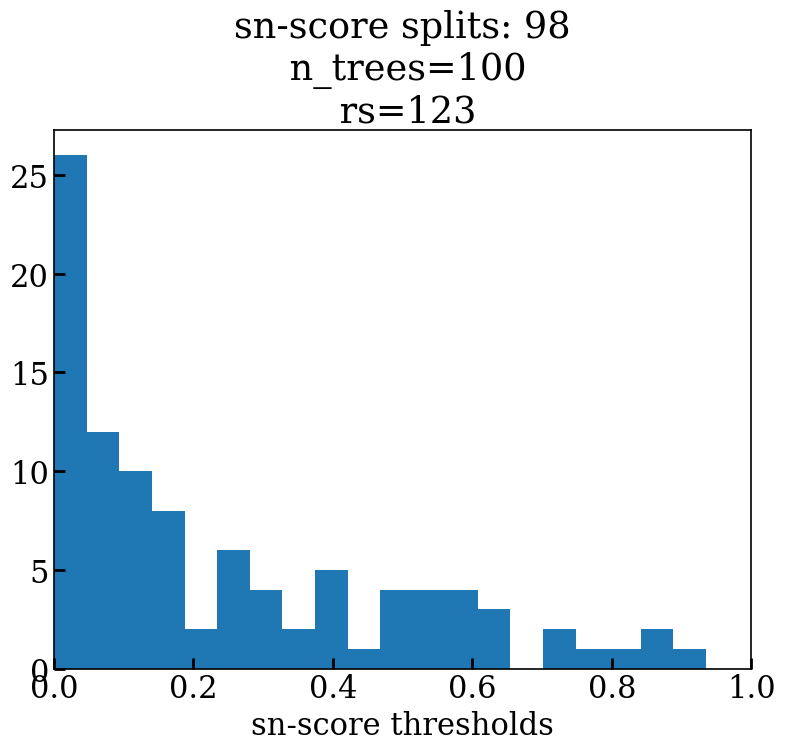

In [8]:
fig, ax = plt.subplots(figsize=(9,7))
plt.hist(sn_threshold, bins=20)
plt.xlabel('sn-score thresholds')
plt.title(f'sn-score splits: {len(sn_threshold)}\n n_trees={n_trees}\n rs={random_seed}')
plt.xlim(0, 1)

# leaf analysis

In [18]:
def get_node_path(n_tree, node, iforest):
    #tree = iforest.estimators_[n_tree].tree_ # sklearn
    tree = iforest.trees[n_tree]  #coniferest
    children_left = tree.children_left
    children_right = tree.children_right
    feature = tree.feature
    threshold = tree.threshold

    if children_left[node] != children_right[node]:
        print(f"Node {node} is not a leaf!")
        return None

    # 2. Поднимаемся от node к корню, собирая путь
    path = [(node, feature[node], threshold[node], 'leaf')]
    current_node = node
    while current_node != 0:  # пока не дошли до корня
        # Определяем, был ли current_node левым или правым потомком
        if current_node in children_left:
            direction = "left"
            parent_node = np.where(children_left == current_node)[0][0]
        else:
            direction = "right"
            parent_node = np.where(children_right == current_node)[0][0]
        # Записываем (родитель, признак, порог, направление)
        path.append((parent_node, feature[parent_node], threshold[parent_node], direction))
        current_node = parent_node

    # 3. Разворачиваем путь, т.к. шли от node к корню, а нужно от корня к node
    path = path[::-1]

    #Выводим путь
    print(f'Tree index: {n_tree}')
    print(f"len(Path) of node {node}: {len(path) - 1}")
    print(f"Path to node {node}:")
    for step in path[:-1]:
        node_id, feat, thr, direction = step
        #right -- False, left -- True
        print(f"Node {node_id}: split X[:, {feat}] <= {thr:.3f}, go {direction}")
        
    node_id, feat, thr, direction = path[-1]
    print(f"Node {node_id} is a leaf")
    #return len(path) - 1


def get_forest_acc(iforest, data, labels):
    total_acc, total_nodes = [], []
    # for estimator in iforest.estimators_: # for sklearn version
    #     tree = estimator.tree_
    for tree in iforest.trees:
        tree_acc = []
        nodes = []
        tree_out = tree.apply(data)
        for cur_node in np.unique(tree_out):
            cur_acc = ((tree_out == cur_node).astype(int) == labels).sum() / len(labels)
            tree_acc.append(cur_acc)
            nodes.append(cur_node)
        tree_acc = np.array(tree_acc)
        total_acc.append(tree_acc)
        total_nodes.append(nodes)
    return total_acc, total_nodes

def get_forest_nodes(iforest, data):
    nodes = []
    # for estimator in iforest.estimators_: # for sklearn version
    #     tree = estimator.tree_
    for tree in iforest.trees:
        tree_out = tree.apply(data)
        nodes.append(tree_out)
    return nodes

def get_tree_id(idx, total_acc, total_nodes):
    cur_tree_id = 0
    cur_length = len(total_acc[cur_tree_id])
    while cur_length < idx + 1:
        cur_tree_id += 1
        cur_length += len(total_acc[cur_tree_id])
    idx_in_tree = idx - (cur_length - len(total_acc[cur_tree_id]))
    acc = total_acc[cur_tree_id][idx_in_tree]
    node = total_nodes[cur_tree_id][idx_in_tree]
    print(f'Accuracy score: {acc:.3f}')
    return acc, node, cur_tree_id

In [13]:
oids, features = load_features('../../dr23-features/sid_snad_clf_r_100.dat', '../../dr23-features/feature_sn.dat')

bts_sn = pd.read_csv('../data/bts_crossmatched_2sec.csv')
bts_crossmatch = np.load(f'../data/bts_dr23_crossmatch.npy')
akb_crossmatch = np.load(f'../data/akb_sn_dr23_crossmatch.npy')
 # тут в качестве негативного класса используются рандомные объекты из дата релиза
bts_features = features[bts_crossmatch] # содержит только SN
akb_sn_features = features[akb_crossmatch]

indx = np.random.choice(np.arange(len(oids)), len(bts_features)+len(akb_sn_features))
regular_obj = features[indx]
train_data = np.vstack([bts_features, regular_obj[:len(bts_features)]])
test_data = np.vstack([akb_sn_features, regular_obj[len(bts_features):]])

train_labels = np.hstack([np.ones(len(bts_features)), np.zeros(len(bts_features))])
test_labels = np.hstack([np.ones(len(akb_sn_features)), np.zeros(len(akb_sn_features))])

In [50]:
n_trees = 100
random_seed = 4

#iforest_sk = IsolationForest(random_state=random_seed, n_jobs=20, n_estimators=n_trees).fit(features[:int(1e8)])  #sklearn
# rb_proba = np.memmap('../../dr23-features/RBclf_proba.dat', mode='c', dtype=np.float32)[:int(1e8)]
# mu, sigma = np.mean(rb_proba), np.std(rb_proba)  # параметры нормального распределения
# uniform_proba = norm.cdf(rb_proba, loc=mu, scale=sigma)

# transf_feat = np.hstack([features[:int(1e8), :-1], uniform_proba.reshape(-1,1)])

In [51]:
iforest = IsolationForest(random_seed=random_seed, n_jobs=22, n_trees=n_trees).fit(features) # coniferst

In [52]:
total_acc, total_nodes = get_forest_acc(iforest, train_data, train_labels)

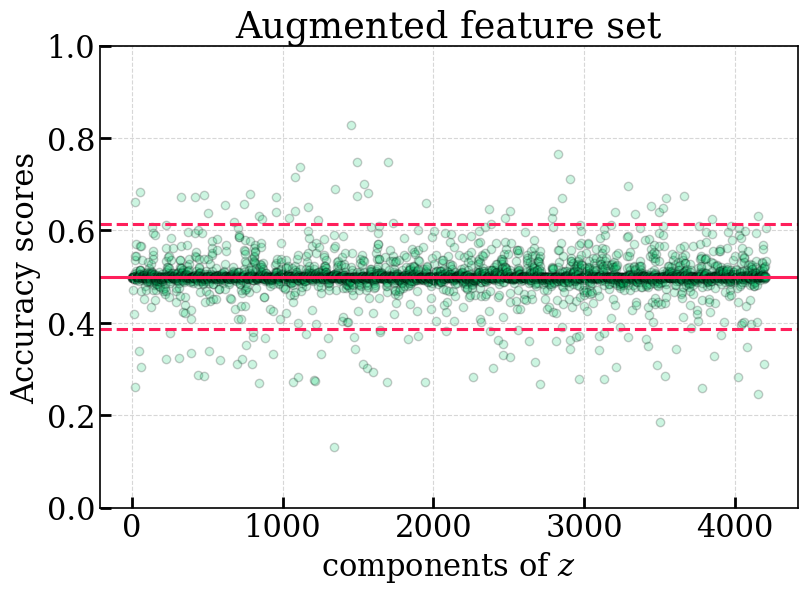

In [53]:
fig, ax = plt.subplots(figsize=(9,6))
plt.scatter(np.arange(len(np.concat(total_acc))), np.concat(total_acc), color=u'#00CD6C', alpha=0.2, edgecolors='black')#u'#00CD6C'  u'#009ADE'  u'#FFC61E'  u'#AF58BA'
plt.axhline(y=0.5, color=u'#FF1F5B', linestyle='-', label=r'$\mu$')
plt.axhline(y=0.5+3*np.std(np.concat(total_acc)), color=u'#FF1F5B', linestyle='--', alpha=1)
plt.axhline(y=0.5-3*np.std(np.concat(total_acc)), color=u'#FF1F5B', linestyle='--', alpha=1, label=r'$\pm3\sigma$')
plt.xlabel('components of $z$')
plt.ylabel('Accuracy scores')
plt.title('Augmented feature set')
plt.ylim(0,1)
ax.grid('on')

In [49]:
acc, node, tree_id = get_tree_id(np.argmax(np.concat(total_acc)), total_acc, total_nodes)
path_len = get_node_path(tree_id, node, iforest)

Accuracy score: 0.784
Tree index: 26
len(Path) of node 24: 5
Path to node 24:
Node 0: split X[:, 16] <= 0.182, go left
Node 1: split X[:, 20] <= 53.023, go left
Node 2: split X[:, 41] <= 0.090, go left
Node 3: split X[:, 31] <= 2.011, go right
Node 23: split X[:, 39] <= 0.510, go left
Node 24 is a leaf


In [39]:
t = time.monotonic()
scores = iforest.score_samples(features[:int(1e7)])
print(f'Score sampling in {(time.monotonic() - t) / 60 :.1f}')

Score sampling in 0.7


In [40]:
t = time.monotonic()
arg_sort = np.argsort(scores)
print(f'Sorted in {(time.monotonic() - t) / 60 :.1f}')

Sorted in 0.0


In [41]:
anom = features[arg_sort[:100]]

In [42]:
anom_nodes = get_forest_nodes(iforest, anom)

In [48]:
anom_fall = (anom_nodes[tree_id] == node).sum()

In [51]:
result = []
result.append([random_seed, acc, node, tree_id, anom_fall])

In [52]:
import pandas as pd
pd.DataFrame(data=result, columns=['random seed', 'Accuracy score', 'Node id', 'Tree id', 'Top-100 anomaly count'])

,random seed,Accuracy score,Node id,Tree id,Top-100 anomaly count
0,22,0.933494,62,214,54


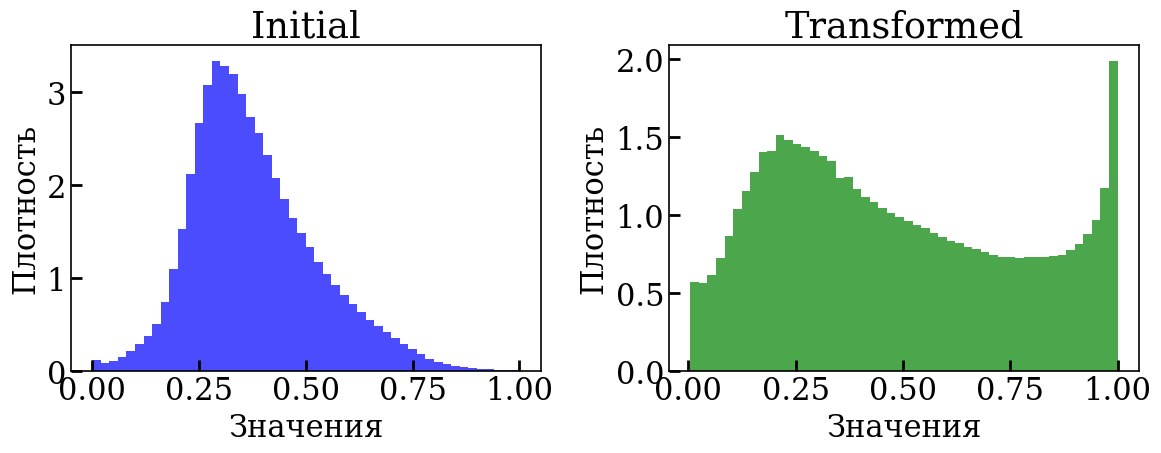

In [55]:
from scipy.stats import norm

# Генерируем данные из нормального распределения
rb_proba = np.memmap('../../dr23-features/RBclf_proba.dat', mode='c', dtype=np.float32)[:int(1e8)]
mu, sigma = np.mean(rb_proba), np.std(rb_proba)  # параметры нормального распределения

#mu, sigma = 0, 1  # параметры нормального распределения
#rb_proba = np.random.normal(mu, sigma, 10000)
# Преобразуем в равномерное распределение с помощью CDF нормального распределения
uniform_data = norm.cdf(rb_proba, loc=mu, scale=sigma)

# Визуализируем результаты
plt.figure(figsize=(12, 5))

# Гистограмма исходных нормальных данных
plt.subplot(1, 2, 1)
plt.hist(rb_proba, bins=50, density=True, alpha=0.7, color='blue')
plt.title('Initial')
plt.xlabel('Значения')
plt.ylabel('Плотность')

# Гистограмма преобразованных равномерных данных
plt.subplot(1, 2, 2)
plt.hist(uniform_data, bins=50, density=True, alpha=0.7, color='green')
plt.title('Transformed')
plt.xlabel('Значения')
plt.ylabel('Плотность')

plt.tight_layout()
plt.show()

# Проверим равномерность с помощью теста Колмогорова-Смирнова
# from scipy.stats import kstest
# ks_stat, p_value = kstest(uniform_data, 'uniform')
# print(f"K-S тест: статистика = {ks_stat:.4f}, p-value = {p_value:.4f}")

# if p_value > 0.05:
#     print("Не отвергаем нулевую гипотезу: данные равномерны")
# else:
#     print("Отвергаем нулевую гипотезу: данные не равномерны")